In [31]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim.adam as adam
from transformers import AutoConfig, AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from collections import Counter
import time
from sklearn.metrics import f1_score
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import itertools

In [32]:
df_comment = pd.read_csv('/kaggle/input/digikala-dataset/original.csv')
df_comment_test = pd.read_csv('/kaggle/input/digikala-dataset/test.csv')

In [34]:
train_comment = df_comment.iloc[:,0].values

In [35]:
train_labels = df_comment.iloc[:,1].values

In [36]:
test_comment = df_comment_test.iloc[:,0].values
test_labels = df_comment_test.iloc[:,1].values

In [37]:
augment_train = augment['Sentences'].values

In [38]:
a = train_labels.shape[0]
b = test_labels.shape[0]

In [39]:
a

5560

In [ ]:
tokenized_list = [tokenizer.tokenize(text) for text in train_comment_list]

In [ ]:
ntoken = 0
for i in range(len(tokenized_list)):
    ntoken = ntoken + len(tokenized_list[i])
print("number of tokens: ", ntoken)

number of tokens:  186867


In [ ]:
train_comment_list = list(train_comment)

In [ ]:
def backtranslate(sentence, target_language='en'):
    translator = Translator()
    translated = translator.translate(sentence, dest=target_language)
    time.sleep(0.5)
    backtranslated = translator.translate(translated.text, src=target_language, dest='fa')
    return backtranslated.text

original_sentence = "سلام عزیزم، چطوری، چیکار میکنی؟"
backtranslated_sentence = backtranslate(original_sentence)

print(f"Original: {original_sentence}")
print(f"Backtranslated: {backtranslated_sentence}")
#n = 0
back = []
for comment in train_comment_list:
    backtranslated_sentence = backtranslate(comment)
    back.append(backtranslated_sentence)

Original: سلام عزیزم، چطوری، چیکار میکنی؟

Backtranslated: سلام عزیزم حالت چطوره؟


In [ ]:
len(back)

5560

In [ ]:
for i in range(10):
    print("from original dataset: ", train_comment_list[i+10])
    print("after back translation: ", back[i+10])


from original dataset:  البته تنها کیفیت بالای تاچ پد،  دلیل این امر نیست و یکپارچه بودن سیستم عامل OS X نیز با فرمان‌های لمسی ،  در این امر بسیار موثر است.

after back translation:  البته کیفیت بالای تاچ پد تنها دلیل این امر نیست و ادغام سیستم عامل OS X با دستورات لمسی نیز در این امر بسیار موثر است.

from original dataset:  اينبار اپل ترکوند  واقعا خيلي گوشيه زيباييه ولي از لحاظ سخت افزاري هنوز يکمي مونده تا به S3 برسه





after back translation:  این بار Apple Turquoise واقعاً گوشی بسیار زیبایی است، اما از نظر سخت افزاری هنوز کمی تا رسیدن به S3 باقی مانده است.

from original dataset:  ولی افزایش پرینت ها به 20 صفحه باعث شد که بتوانیم به سرعت 15.8 صفحه در دقیقه برسیم که این چیزی در حدود 75 درصد سرعت ادعایی HP است.

after back translation:  اما افزایش چاپ به 20 صفحه به ما اجازه داد تا به سرعت 15.8 صفحه در دقیقه برسیم که حدود 75 درصد سرعت ادعایی HP است.

from original dataset:  توي قيمت بهترين گوشي هست.

after back translation:  نسبت به قیمتش بهترین گوشیه

from original dataset:  اما ب

In [ ]:
df = pd.DataFrame(back, columns=["Sentences"])

In [ ]:
file_path = '/kaggle/input/digikala-dataset/sentences_dataframe.csv'

df.to_csv(file_path, index=False) 

In [ ]:
augment = pd.read_csv('/kaggle/input/digikala-dataset/sentences_dataframe.csv')

In [33]:
augment

,Sentences
0,سلام خیلی خوب بخر
1,از قابلیت های ارتباطی HTC Desire SV می توان به...
2,در نهایت یک دوربین VGA نیز در جلوی گوشی برای م...
3,من حدود 1 ماهه که این گوشی رو دارم و راضی هستم...
4,اندازه نسبتا خوب و وزن خوب 4.
...,...
5555,Dock Tablet همچنین دارای صفحه نمایش 10.1 اینچی...
5556,صفحه نمایش این گوشی کیفیت بسیار خوب و راضی کنن...
5557,این فقط یک جواب دارد و آن ادبیات کاربر است!
5558,بر خلاف همه پیش بینی های اغراق آمیز.


In [40]:
for i in range(a):
    if train_labels[i] == -1 or train_labels[i] == -2:
        train_labels[i] = -1
    if train_labels[i] == 1 or train_labels[i] == 2:
        train_labels[i] = 1

In [41]:
train_labels

array([1, 0, 0, ..., 0, 0, 1])

In [42]:
for i in range(b):
    if test_labels[i] == -1 or test_labels[i] == -2:
        test_labels[i] = -1
    if test_labels[i] == 1 or test_labels[i] == 2:
        test_labels[i] = 1

In [43]:
test_labels

array([-1,  1,  1, ...,  0,  1,  1])

In [44]:
num_0 = 0
num_1 = 0
num_minus_1 = 0
for i in range(a):
    if train_labels[i] == 1:
         num_1 += 1
    if train_labels[i] == -1:
         num_minus_1 += 1
    if train_labels[i] == 0:
        num_0 += 1

In [45]:
num_0 + num_1 + num_minus_1

5560

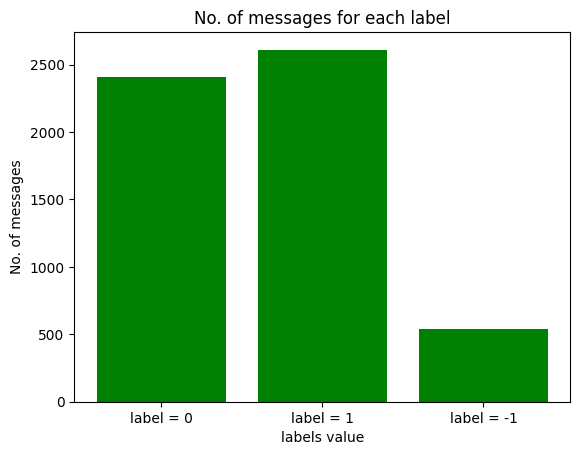

In [46]:
x=[num_0,num_1,num_minus_1]
xpoints = np.array(['label = 0','label = 1','label = -1'])
plt.bar(xpoints, x, color='green', width=0.8)
plt.xlabel("labels value")
plt.ylabel("No. of messages")
plt.title("No. of messages for each label")
plt.show()

In [47]:
tokenizer = AutoTokenizer.from_pretrained("sbunlp/fabert") 
fabert = AutoModel.from_pretrained("sbunlp/fabert")

Some weights of BertModel were not initialized from the model checkpoint at sbunlp/fabert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [48]:
tweets1, tweets1_valid, labels1, labels1_valid = train_test_split(train_comment, train_labels, test_size=0.25)

print("Training set size:", len(tweets1))
print("Validation set size:", len(tweets1_valid))


tweets3, tweets3_valid, labels3, labels3_valid = train_test_split(augment_train, train_labels, test_size=0.25)

print("Training set size:", len(tweets3))
print("Validation set size:", len(tweets3_valid))

Training set size: 4170
Validation set size: 1390
Training set size: 4170
Validation set size: 1390


In [49]:
input_ids1 = []
attention_masks1 = []
for tweet in tweets1:
    encoded_dict = tokenizer.encode_plus(
                        tweet,
                        add_special_tokens = True,
                        max_length = 512,
                        pad_to_max_length = True,
                        return_attention_mask = True,
                        truncation=True,
                        return_tensors = 'pt',
                   )

    input_ids1.append(encoded_dict['input_ids'])

    attention_masks1.append(encoded_dict['attention_mask'])
input_ids1 = torch.cat(input_ids1, dim=0)
attention_masks1 = torch.cat(attention_masks1, dim=0)
labels1 = labels1.astype(np.float32)
labels1 = torch.tensor(labels1).view(-1,1)

print('Original: ', tweets1[0])
print('Token IDs:', input_ids1[0])

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:2699: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


Original:  مطالبي که عرض کردم به سادگي قابل قضاوت است!
Token IDs: tensor([  101,  4179,  1407,  2307,  3713,  2917,  2299, 14017,  1306,  1407,
         2970,  6890,  2317,   104,   102,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0

In [52]:
input_ids1

tensor([[  101,  4179,  1407,  ...,     0,     0,     0],
        [  101,  2297, 24967,  ...,     0,     0,     0],
        [  101,  2872,  2331,  ...,     0,     0,     0],
        ...,
        [  101,  8249,   589,  ...,     0,     0,     0],
        [  101,  2447, 10335,  ...,     0,     0,     0],
        [  101, 25344,   589,  ...,     0,     0,     0]])

In [20]:
input_ids1_valid = []
attention_masks1_valid = []
for tweet in tweets1_valid:
    encoded_dict = tokenizer.encode_plus(
                        tweet,
                        add_special_tokens = True,
                        max_length = 512,
                        pad_to_max_length = True,
                        return_attention_mask = True,
                        truncation=True,
                        return_tensors = 'pt',
                   )

    input_ids1_valid.append(encoded_dict['input_ids'])

    attention_masks1_valid.append(encoded_dict['attention_mask'])
input_ids1_valid = torch.cat(input_ids1_valid, dim=0)
attention_masks1_valid = torch.cat(attention_masks1_valid, dim=0)
labels1_valid = labels1_valid.astype(np.float32)
labels1_valid = torch.tensor(labels1_valid).view(-1,1)

print('Original: ', tweets1_valid[0])
print('Token IDs:', input_ids1_valid[0])

Original:  يا شايد هم در مقابل دارندگان ps3 شرمنده شويم!
Token IDs: tensor([  101,   624,  1303,  3117,  1407,  1302,  2323,  2297,  3632, 18879,
        27678,  1335, 10267,  3472,  1407,  1309,   104,   102,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,    

In [21]:
tweets2 = test_comment
labels2 = test_labels

In [22]:
input_ids2 = []
attention_masks2 = []
for tweet in tweets2:
    encoded_dict = tokenizer.encode_plus(
                        tweet,
                        add_special_tokens = True,
                        max_length = 512,
                        pad_to_max_length = True,
                        return_attention_mask = True,
                        truncation=True,
                        return_tensors = 'pt',
                   )

    input_ids2.append(encoded_dict['input_ids'])

    attention_masks2.append(encoded_dict['attention_mask'])
input_ids2 = torch.cat(input_ids2, dim=0)
attention_masks2 = torch.cat(attention_masks2, dim=0)
labels2 = labels2.astype(np.float32)

labels2 = torch.tensor(labels2).view(-1,1)

print('Original: ', tweets2[0])
print('Token IDs:', input_ids2[0])

Original:  با اين چيزا نميتونه از Galaxy S III بهتر باشه
Token IDs: tensor([  101,  2305,   589,  1407,  1307,   684,  1407,  4581,  2355,  1407,
         3220,  1314,  2303, 24967,   154, 22771,  1381,  3279,  3380,   102,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,    

In [23]:
input_ids3 = []
attention_masks3 = []
for tweet in tweets3:
    encoded_dict = tokenizer.encode_plus(
                        tweet,
                        add_special_tokens = True,
                        max_length = 512,
                        pad_to_max_length = True,
                        return_attention_mask = True,
                        truncation=True,
                        return_tensors = 'pt',
                   )

    input_ids3.append(encoded_dict['input_ids'])

    attention_masks3.append(encoded_dict['attention_mask'])
input_ids3 = torch.cat(input_ids3, dim=0)
attention_masks3 = torch.cat(attention_masks3, dim=0)
labels3 = labels3.astype(np.float32)

labels3 = torch.tensor(labels3).view(-1,1)

print('Original: ', tweets3[0])
print('Token IDs:', input_ids3[0])

Original:  دوست ما در نقد بالا در مورد سقوط نوکیا نوشته است اما بسیاری از سایت ها این گوشی را با این قیمت پایین ناجی ویندوزفون و نوکیا می دانند.
Token IDs: tensor([  101,  2606,  2418,  2297,  5375,  2940,  2297,  2556,  6867, 14454,
         3421,  2317,  2472,  3344,  2303,  3316,  6173,  2314,  5024,  2311,
         2305,  2314,  3384,  3410, 21370,  6127,  7434,   622, 14454,  2394,
        34045,   117,   102,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0, 

In [ ]:
input_ids3_valid = []
attention_masks3_valid = []
for tweet in tweets3_valid:
    encoded_dict = tokenizer.encode_plus(
                        tweet,
                        add_special_tokens = True,
                        max_length = 512,
                        pad_to_max_length = True,
                        return_attention_mask = True,
                        truncation=True,
                        return_tensors = 'pt',
                   )

    input_ids3_valid.append(encoded_dict['input_ids'])

    attention_masks3_valid.append(encoded_dict['attention_mask'])
input_ids3_valid = torch.cat(input_ids3_valid, dim=0)
attention_masks3_valid = torch.cat(attention_masks3_valid, dim=0)
labels3_valid = labels3_valid.astype(np.float32)

labels3_valid = torch.tensor(labels3_valid).view(-1,1)

print('Original: ', tweets3_valid[0])
print('Token IDs:', input_ids3_valid[0])

In [25]:
labels1 = labels1+1
labels2 = labels2+1
labels3 = labels3+1
labels1_valid = labels1_valid+1
labels3_valid = labels3_valid+1

In [29]:
type(input_ids3_valid)

torch.Tensor

In [75]:
labels1_onehot = torch.eye(3)[labels1.squeeze().long()]

In [76]:
labels2_onehot = torch.eye(3)[labels2.squeeze().long()]
labels3_onehot = torch.eye(3)[labels3.squeeze().long()]
labels1_valid_onehot = torch.eye(3)[labels1_valid.squeeze().long()]
labels3_valid_onehot = torch.eye(3)[labels3_valid.squeeze().long()]

In [77]:
train_dataset1 = TensorDataset(input_ids1, attention_masks1, labels1_onehot)
valid_dataset1 = TensorDataset(input_ids1_valid, attention_masks1_valid, labels1_valid_onehot)
train_dataset2 = TensorDataset(input_ids3, attention_masks3, labels3_onehot)
valid_dataset2 = TensorDataset(input_ids3_valid, attention_masks3_valid, labels3_valid_onehot)
test_dataset = TensorDataset(input_ids2, attention_masks2, labels2_onehot)

In [78]:
batch_size = 4

train_dataloader1 = DataLoader(
            train_dataset1,
            shuffle = True,
            batch_size = batch_size
        )

valid_dataloader1 = DataLoader(
            valid_dataset1,
            shuffle = False,
            batch_size = batch_size
        )
train_dataloader2 = DataLoader(
            train_dataset2,
            shuffle = True,
            batch_size = batch_size
        )

valid_dataloader2 = DataLoader(
            valid_dataset2,
            shuffle = False,
            batch_size = batch_size
        )
test_dataloader = DataLoader(
            test_dataset,
            shuffle = False,
            batch_size = batch_size
        )

In [79]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [83]:
def plot_confusion_matrix(cm,classes,
                          normalize=False,
                          title='confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('confusion matrix, without normalization')
    plt.imshow(cm,interpolation='nearest',cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j,i,format(cm[i,j],fmt),
                horizontalalignment="center",
                color="white" if cm[i,j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('predicted label')
    plt.show()

In [84]:
class fa_BERT(nn.Module):
    def __init__(self, fabert):
        super(fa_BERT, self).__init__()
        self.fabert = fabert
        self.dropout = nn.Dropout(0.1)          
        self.fc1 = nn.Linear(768,512)             
        self.fc2 = nn.Linear(512,256)               
        self.fc3 = nn.Linear(256,3)
        self.relu = nn.ReLU()
    def forward(self, sent_id, mask):          
        cls_hs = self.fabert(sent_id, attention_mask=mask)['pooler_output']
        x = self.fc1(cls_hs)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.fc3(x)                           

        return x

model = fa_BERT(fabert)
for name, param in model.fabert.named_parameters():
    if 'encoder.layer.11' in name:
        param.requires_grad = True
        print(f"this layer {name} is unfreezed")
    elif 'pooler' in name:
        param.requires_grad = True
        print(f"this layer {name} is unfreezed")
    else:
        param.requires_grad = False
        print(f"this layer {name} became freezed")
model.to(device)
learning_rate = 1e-5
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

this layer embeddings.word_embeddings.weight became freezed
this layer embeddings.position_embeddings.weight became freezed
this layer embeddings.token_type_embeddings.weight became freezed
this layer embeddings.LayerNorm.weight became freezed
this layer embeddings.LayerNorm.bias became freezed
this layer encoder.layer.0.attention.self.query.weight became freezed
this layer encoder.layer.0.attention.self.query.bias became freezed
this layer encoder.layer.0.attention.self.key.weight became freezed
this layer encoder.layer.0.attention.self.key.bias became freezed
this layer encoder.layer.0.attention.self.value.weight became freezed
this layer encoder.layer.0.attention.self.value.bias became freezed
this layer encoder.layer.0.attention.output.dense.weight became freezed
this layer encoder.layer.0.attention.output.dense.bias became freezed
this layer encoder.layer.0.attention.output.LayerNorm.weight became freezed
this layer encoder.layer.0.attention.output.LayerNorm.bias became freezed
th

Epoch [1/5], train_accuracy: 0.5129496402877698, train_loss: 0.9351639727046597, valid_accuracy: 0.676978417266187 , valid_loss: 0.8484469883400818 
Epoch [2/5], train_accuracy: 0.7026378896882494, train_loss: 0.7042682542396872, valid_accuracy: 0.7323741007194244 , valid_loss: 0.6346347762764185 
Epoch [3/5], train_accuracy: 0.7390887290167866, train_loss: 0.6080607876024448, valid_accuracy: 0.7402877697841727 , valid_loss: 0.5891547657110482 
Epoch [4/5], train_accuracy: 0.7529976019184652, train_loss: 0.5613810351280958, valid_accuracy: 0.7546762589928058 , valid_loss: 0.5715469746721973 
Epoch [5/5], train_accuracy: 0.7817745803357314, train_loss: 0.5272531652053388, valid_accuracy: 0.7589928057553957 , valid_loss: 0.5870141735482405 


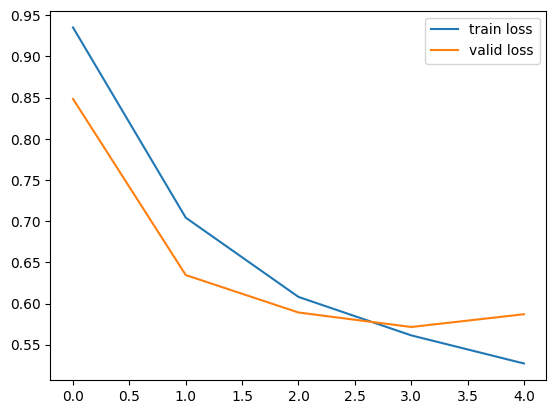

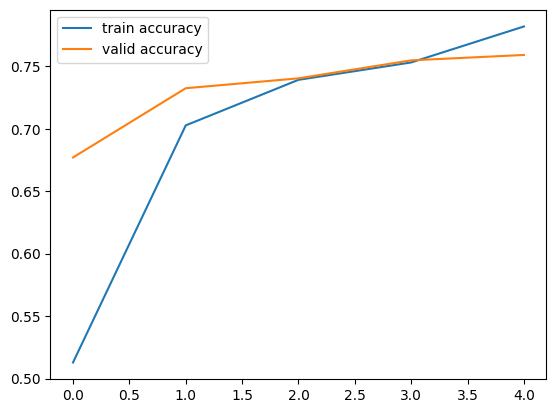

In [85]:
num_epochs = 5

train_losses = np.zeros(num_epochs)
valid_losses = np.zeros(num_epochs)
train_accuracy = np.zeros(num_epochs)
valid_accuracy = np.zeros(num_epochs)
for epoch in range(num_epochs):
    train_loss = []
    valid_loss = []
    n_correct1 = 0
    n_total1 = 0
    model.train()
    for step,batch in enumerate(train_dataloader1):
        input_id = batch[0].to(device)
        attention_mask = batch[1].to(device)
        targets = batch[2].to(device)
        outputs = model(input_id, attention_mask)
        loss = criterion(outputs,targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())
        n_correct1 += torch.sum(outputs.argmax(dim=1) == targets.argmax(dim=1)).item()
        n_total1 += targets.shape[0]


    train_acc = n_correct1 / n_total1

    train_loss=np.mean(train_loss)
    train_losses[epoch] = train_loss
    train_accuracy[epoch] = train_acc
    model.eval()
    n_correct2 = 0
    n_total2 = 0
    for step,batch in enumerate(valid_dataloader1):
        input_id = batch[0].to(device)
        attention_mask = batch[1].to(device)
        targets = batch[2].to(device)
        outputs = model(input_id, attention_mask)
        loss = criterion(outputs, targets)
        valid_loss.append(loss.item())
        n_correct2 += torch.sum(outputs.argmax(dim=1) == targets.argmax(dim=1)).item()
        n_total2 += targets.shape[0]

    valid_acc = n_correct2 / n_total2
    valid_loss=np.mean(valid_loss)
    valid_accuracy[epoch] = valid_acc
    valid_losses[epoch] = valid_loss



    print(f"Epoch [{epoch+1}/{num_epochs}], train_accuracy: {train_acc}, train_loss: {train_loss}, valid_accuracy: {valid_acc} , valid_loss: {valid_loss} ")
plt.plot(train_losses, label='train loss')
plt.plot(valid_losses, label='valid loss')
plt.legend()
plt.show()
plt.plot(train_accuracy, label='train accuracy')
plt.plot(valid_accuracy, label='valid accuracy')
plt.legend()
plt.show()


 با اين چيزا نميتونه از Galaxy S III بهتر باشه

 در کل،  با اینکه عکاسی با تبلت را همواره جزو موارد غیر ضروری نامیده‌ایم،  ولی در مورد این دستگاه برای کسانی که علاقه‌مند به عکاسی نیز هستند،  هواوی شرایطی را فراهم نموده است که کاملا آن‌ها را راضی خواهد نمود.

 پهناي باند حافظه

پهناي باندي که در حافظه‌ي موجود وجود دارد،  حدود ۲۵۶ گيگابايت در ثانيه است که ارتباط سريع ميان واحدها را با کمترين تاخير مهيا مي‌کند.

 همه ميدانيم که اين گوشي از سيستم عامل ios6 پشتيباني ميکند سيستم عاملي که رييس شرکت سامسونگ در معرفي گلکسي نوت2 دربارش ميگويد:اين سيستم عامل بي نظير و دست نيافتني است و من ارزو دارم روزي از اين سيستم عامل بر روي گوشي هاي سامسونگ استفاده کنم.

 تازه گارانتيشم که بخاطر ت ح ر ي م !

 منم چند روزي ميشه که گرفتم.
confusion matrix, without normalization


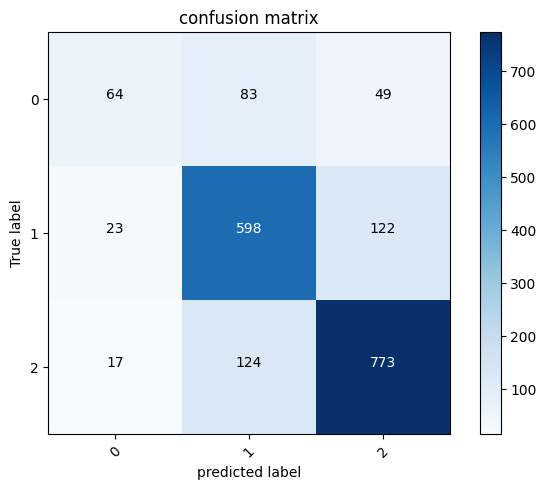

test_accuracy: 0.7744198596869941, test_loss: 0.5572638608162003
(1853,)
  F1 score: 0.6771179961597263


In [86]:
test_loss = []
n_correct = 0
n_total = 0
y_true = []
y_pred = []
y_test = labels2_onehot
p_test = np.array([])
i = 0
j = 0
with torch.no_grad():
    for step,batch in enumerate(test_dataloader):
        input_id = batch[0].to(device)
        attention_mask = batch[1].to(device)
        targets = batch[2].to(device) 
        outputs = model(input_id, attention_mask)
        loss = criterion(outputs,targets)
        test_loss.append(loss.item())
        n_correct += torch.sum(outputs.argmax(dim=1) == targets.argmax(dim=1)).item()
        n_total += targets.shape[0] 
        y_true.append(targets.argmax(dim=1).flatten())
        y_pred.append(outputs.argmax(dim=1))
        p_test = np.concatenate((p_test, outputs.argmax(dim=1).detach().cpu().numpy().reshape(-1)))
        if j<=5:
            a = torch.sum(outputs.argmax(dim=1) != targets.argmax(dim=1)).item()
            if a != 0:
                if (outputs.argmax(dim=1)[0] != targets.argmax(dim=1))[0]:
                    print("\n",test_comment[i*4])
                    j = j+1
                if (outputs.argmax(dim=1)[1] != targets.argmax(dim=1))[1]:
                    j = j+1
                    print("\n",test_comment[i*4+1])
                if (outputs.argmax(dim=1)[2] != targets.argmax(dim=1))[2]:
                    j = j+1
                    print("\n",test_comment[i*4+2])
                if (outputs.argmax(dim=1)[3] != targets.argmax(dim=1))[0]:
                    j = j+1
                    print("\n",test_comment[i*4+3])
        i=i+1
        


y_pred = torch.cat(y_pred, dim=0)
y_pred = y_pred.detach().cpu().numpy()
cm = confusion_matrix(labels2_onehot.argmax(dim=1),p_test)
test_acc = n_correct / n_total
test_loss=np.mean(test_loss)
plot_confusion_matrix(cm,list(range(3)))
print(f"test_accuracy: {test_acc}, test_loss: {test_loss}")
print(y_pred.shape)
print('  F1 score:',f1_score(labels2_onehot.argmax(dim=1), y_pred, average='macro'))

In [87]:
class fa_BERT2(nn.Module):
    def __init__(self, fabert):
        super(fa_BERT2, self).__init__()
        self.fabert = fabert
        self.dropout = nn.Dropout(0.1)            # dropout layer
        self.fc1 = nn.Linear(768,512)             # dense layer 1
        self.fc2 = nn.Linear(512,256)               # dense layer 2
        self.fc3 = nn.Linear(256,3)
        self.relu = nn.ReLU()
    def forward(self, sent_id, mask):           # define the forward pass
        cls_hs = self.fabert(sent_id, attention_mask=mask)['pooler_output']
        x = self.fc1(cls_hs)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.fc3(x)

        return x

model2 = fa_BERT2(fabert)
for name, param in model2.fabert.named_parameters():
    if 'encoder.layer.11' in name:
        param.requires_grad = True
        print(f"this layer {name} is unfreezed")
    elif 'pooler' in name:
        param.requires_grad = True
        print(f"this layer {name} is unfreezed")
    else:
        param.requires_grad = False
        print(f"this layer {name} became freezed")
model2.to(device)
learning_rate = 1e-5
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=learning_rate)

this layer embeddings.word_embeddings.weight became freezed
this layer embeddings.position_embeddings.weight became freezed
this layer embeddings.token_type_embeddings.weight became freezed
this layer embeddings.LayerNorm.weight became freezed
this layer embeddings.LayerNorm.bias became freezed
this layer encoder.layer.0.attention.self.query.weight became freezed
this layer encoder.layer.0.attention.self.query.bias became freezed
this layer encoder.layer.0.attention.self.key.weight became freezed
this layer encoder.layer.0.attention.self.key.bias became freezed
this layer encoder.layer.0.attention.self.value.weight became freezed
this layer encoder.layer.0.attention.self.value.bias became freezed
this layer encoder.layer.0.attention.output.dense.weight became freezed
this layer encoder.layer.0.attention.output.dense.bias became freezed
this layer encoder.layer.0.attention.output.LayerNorm.weight became freezed
this layer encoder.layer.0.attention.output.LayerNorm.bias became freezed
th

Epoch [1/5], train_accuracy: 0.7558752997601919, train_loss: 0.600258775646526, valid_accuracy: 0.7877697841726619 , valid_loss: 0.5259744625688455 
Epoch [2/5], train_accuracy: 0.8002398081534772, train_loss: 0.48752565196003633, valid_accuracy: 0.7992805755395683 , valid_loss: 0.521501259144995 
Epoch [3/5], train_accuracy: 0.8151079136690648, train_loss: 0.4554429108960945, valid_accuracy: 0.7942446043165468 , valid_loss: 0.5173198309908996 
Epoch [4/5], train_accuracy: 0.8268585131894485, train_loss: 0.4224388389870496, valid_accuracy: 0.7942446043165468 , valid_loss: 0.5581578561158358 
Epoch [5/5], train_accuracy: 0.8287769784172662, train_loss: 0.40388546895400074, valid_accuracy: 0.7971223021582734 , valid_loss: 0.5691616503393342 


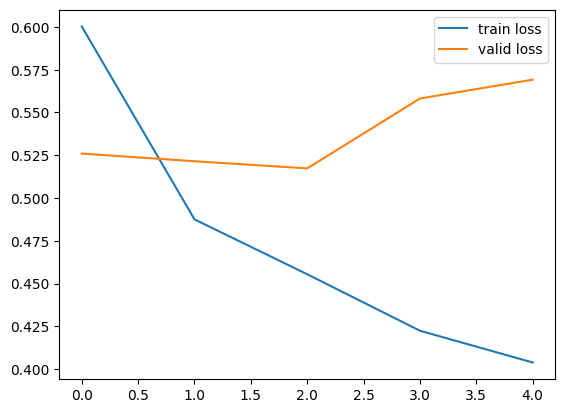

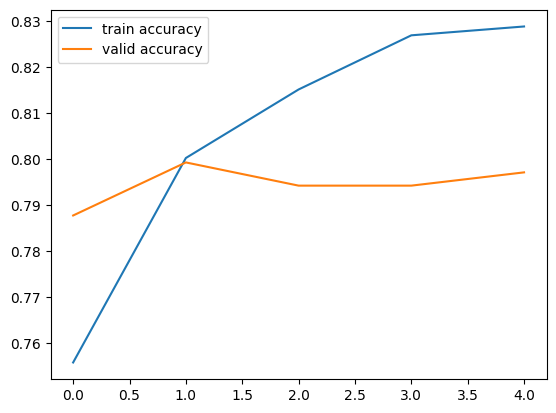

In [88]:
num_epochs = 5

train_losses = np.zeros(num_epochs)
valid_losses = np.zeros(num_epochs)
train_accuracy = np.zeros(num_epochs)
valid_accuracy = np.zeros(num_epochs)
for epoch in range(num_epochs):
    train_loss = []
    valid_loss = []
    n_correct1 = 0
    n_total1 = 0
    model2.train()
    for step,batch in enumerate(train_dataloader2):
        input_id = batch[0].to(device)
        attention_mask = batch[1].to(device)
        targets = batch[2].to(device)
        outputs = model2(input_id, attention_mask)
        loss = criterion(outputs,targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())
        n_correct1 += torch.sum(outputs.argmax(dim=1) == targets.argmax(dim=1)).item()
        n_total1 += targets.shape[0]


    train_acc = n_correct1 / n_total1

    train_loss=np.mean(train_loss)
    train_losses[epoch] = train_loss
    train_accuracy[epoch] = train_acc
    model2.eval()
    n_correct2 = 0
    n_total2 = 0
    for step,batch in enumerate(valid_dataloader2):
        input_id = batch[0].to(device)
        attention_mask = batch[1].to(device)
        targets = batch[2].to(device)
        outputs = model2(input_id, attention_mask)
        loss = criterion(outputs, targets)
        valid_loss.append(loss.item())
        n_correct2 += torch.sum(outputs.argmax(dim=1) == targets.argmax(dim=1)).item()
        n_total2 += targets.shape[0]

    valid_acc = n_correct2 / n_total2
    valid_loss=np.mean(valid_loss)
    valid_accuracy[epoch] = valid_acc
    valid_losses[epoch] = valid_loss



    print(f"Epoch [{epoch+1}/{num_epochs}], train_accuracy: {train_acc}, train_loss: {train_loss}, valid_accuracy: {valid_acc} , valid_loss: {valid_loss} ")
plt.plot(train_losses, label='train loss')
plt.plot(valid_losses, label='valid loss')
plt.legend()
plt.show()
plt.plot(train_accuracy, label='train accuracy')
plt.plot(valid_accuracy, label='valid accuracy')
plt.legend()
plt.show()


 با اين چيزا نميتونه از Galaxy S III بهتر باشه

 در کل،  با اینکه عکاسی با تبلت را همواره جزو موارد غیر ضروری نامیده‌ایم،  ولی در مورد این دستگاه برای کسانی که علاقه‌مند به عکاسی نیز هستند،  هواوی شرایطی را فراهم نموده است که کاملا آن‌ها را راضی خواهد نمود.

 پهناي باند حافظه

پهناي باندي که در حافظه‌ي موجود وجود دارد،  حدود ۲۵۶ گيگابايت در ثانيه است که ارتباط سريع ميان واحدها را با کمترين تاخير مهيا مي‌کند.

 همه ميدانيم که اين گوشي از سيستم عامل ios6 پشتيباني ميکند سيستم عاملي که رييس شرکت سامسونگ در معرفي گلکسي نوت2 دربارش ميگويد:اين سيستم عامل بي نظير و دست نيافتني است و من ارزو دارم روزي از اين سيستم عامل بر روي گوشي هاي سامسونگ استفاده کنم.

 تازه گارانتيشم که بخاطر ت ح ر ي م !

 منم چند روزي ميشه که گرفتم.
confusion matrix, without normalization


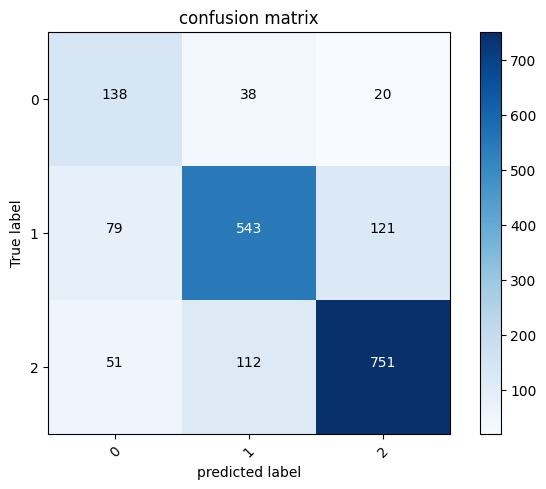

test_accuracy: 0.7728008634646519, test_loss: 0.5340780838741921
(1853,)
  F1 score: 0.7275890664809586


In [89]:
test_loss = []
n_correct = 0
n_total = 0
y_true = []
y_pred = []
y_test = labels2_onehot
p_test = np.array([])
i = 0
j = 0
with torch.no_grad():
    for step,batch in enumerate(test_dataloader):
        input_id = batch[0].to(device)
        attention_mask = batch[1].to(device)
        targets = batch[2].to(device) 
        outputs = model2(input_id, attention_mask)
        loss = criterion(outputs,targets)
        test_loss.append(loss.item())
        n_correct += torch.sum(outputs.argmax(dim=1) == targets.argmax(dim=1)).item()
        n_total += targets.shape[0] 
        y_true.append(targets.argmax(dim=1).flatten())
        y_pred.append(outputs.argmax(dim=1))
        p_test = np.concatenate((p_test, outputs.argmax(dim=1).detach().cpu().numpy().reshape(-1)))
        if j<=5:
            a = torch.sum(outputs.argmax(dim=1) != targets.argmax(dim=1)).item()
            if a != 0:
                if (outputs.argmax(dim=1)[0] != targets.argmax(dim=1))[0]:
                    print("\n",test_comment[i*4])
                    j = j+1
                if (outputs.argmax(dim=1)[1] != targets.argmax(dim=1))[1]:
                    j = j+1
                    print("\n",test_comment[i*4+1])
                if (outputs.argmax(dim=1)[2] != targets.argmax(dim=1))[2]:
                    j = j+1
                    print("\n",test_comment[i*4+2])
                if (outputs.argmax(dim=1)[3] != targets.argmax(dim=1))[0]:
                    j = j+1
                    print("\n",test_comment[i*4+3])
        i=i+1
        


y_pred = torch.cat(y_pred, dim=0)
y_pred = y_pred.detach().cpu().numpy()
cm = confusion_matrix(labels2_onehot.argmax(dim=1),p_test)
test_acc = n_correct / n_total
test_loss=np.mean(test_loss)
plot_confusion_matrix(cm,list(range(3)))
print(f"test_accuracy: {test_acc}, test_loss: {test_loss}")
print(y_pred.shape)
print('  F1 score:',f1_score(labels2_onehot.argmax(dim=1), y_pred, average='macro'))